<a href="https://colab.research.google.com/github/adilkamal2478/Adil_Pandas_campusx/blob/main/Session_24_my_task_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from io import StringIO

from sklearn.preprocessing import LabelEncoder

plt.style.use('default')

## **Problem 1 to 2:**

**Dataset link:** https://rb.gy/gsmddu

**Add a label to every axis and add a proper title for the charts (For every subplot, it is applicable). Also add proper labels if there are multiple representations.** Then, you can customize it as your wish.

In [71]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [72]:
df = pd.read_csv('/content/drive/MyDrive/Matplotlib_CampusX/Session_24_task/PowerGeneration - PowerGeneration.csv')
df.head(3)

,Dates,Power Station,Monitored Cap.(MW),Total Cap. Under Maintenace (MW),Planned Maintanence (MW),Forced Maintanence(MW),Other Reasons (MW),Programme or Expected(MU),Actual(MU),Excess(+) / Shortfall (-),Deviation
0,2017-09-01,Delhi,2235.4,135.0,0.0,135.0,0,13,18,5.00,0.0
1,2017-09-01,Haryana,2720.0,2470.0,0.0,2470.0,0,28,7,-21.80,0.0
2,2017-09-01,Himachal Pradesh,3378.0,379.0,0.0,231.0,0,40,46,5.63,0.0


### **Problem-1:** Make a subplots which have 2 plots.

- For the first chart, draw a scatter plot "*Monitored Cap.(MW)*" vs "*Total Cap. Under Maintenance (MW)*" of top 5 most frequent power stations. Then draw the lines which indicate the average values of these two columns. Change the colors according to the names of the Power Stations.
- For the second chart, draw a scatter plot "*Monitored Cap. (MW)*" vs "*Actual(MU)*" of the top 5 most frequent power stations. Also draw the lines which indicates the average values of these two columns. Change the colors according to the names of the Power Stations.


In [73]:
temp = df['Power Station'].value_counts().head().reset_index()
temp

temp_df = df[df['Power Station'].isin(temp['Power Station'])]
temp_df

encoder = LabelEncoder()
temp_df['Power Station'] = encoder.fit_transform(temp_df['Power Station'])

/tmp/ipykernel_1275/3277512472.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df['Power Station'] = encoder.fit_transform(temp_df['Power Station'])


Text(0.5, 1.0, 'Monitored Vs Actual(MU)')

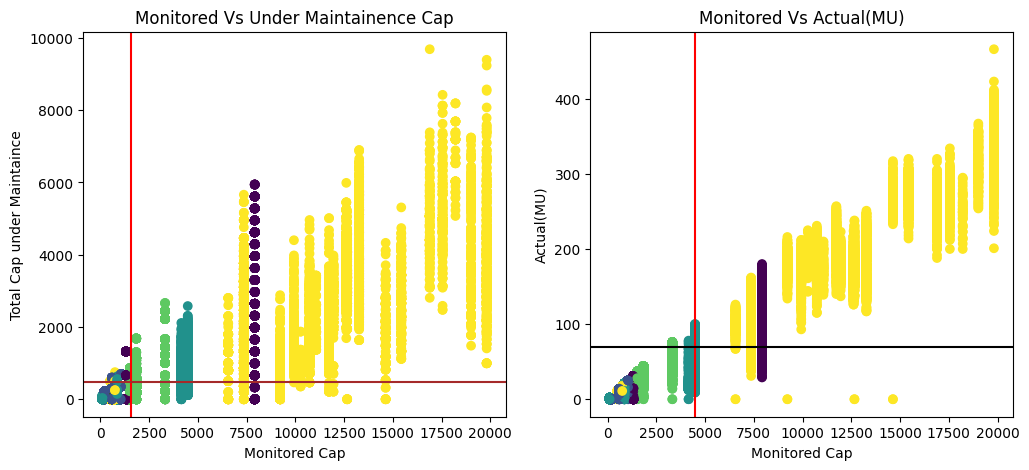

In [75]:
fig , ax = plt.subplots(figsize = (12,5) , ncols= 2)

ax[0].scatter(temp_df['Monitored Cap.(MW)'] , temp_df['Total Cap. Under Maintenace (MW)'] ,c=temp_df['Power Station'])


ax[0].axvline(df['Monitored Cap.(MW)'].mean() , color = 'red')
ax[0].axhline(df['Total Cap. Under Maintenace (MW)'].mean() , color = 'brown')
ax[0].set_xlabel('Monitored Cap')
ax[0].set_ylabel('Total Cap under Maintaince')
ax[0].set_title('Monitored Vs Under Maintainence Cap')

ax[1].scatter(temp_df['Monitored Cap.(MW)'],temp_df['Actual(MU)'],c=temp_df['Power Station'])
ax[1].axvline(temp_df['Monitored Cap.(MW)'].mean(),c='red')
ax[1].axhline(temp_df['Actual(MU)'].mean(),c='black')
ax[1].set_xlabel('Monitored Cap')
ax[1].set_ylabel('Actual(MU)')
ax[1].set_title('Monitored Vs Actual(MU)')


### **Problem-2:** Draw a 3D Scatter plot between "*Monitored Cap.(MW)*", "*Total Cap. Under Maintenace (MW)*" and "*Forced Maintanence(MW)*"

Text(0.5, 0.92, '3D plot of various metrics')

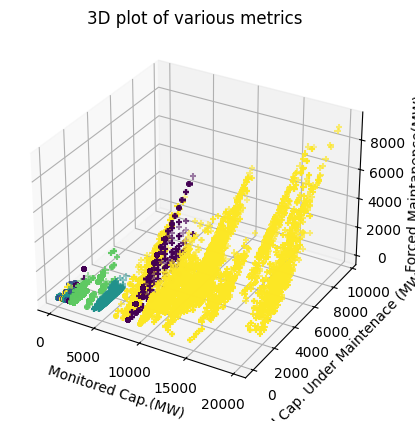

In [88]:
fig = plt.figure()
ax = plt.subplot(projection = '3d')
ax.scatter3D(temp_df[ "Monitored Cap.(MW)"] , temp_df[ "Total Cap. Under Maintenace (MW)"] , temp_df["Forced Maintanence(MW)"]  , c=temp_df['Power Station'] , marker = '+')

ax.set_xlabel('Monitored Cap.(MW)')
ax.set_ylabel('Total Cap. Under Maintenace (MW)')
ax.set_zlabel('Forced Maintanence(MW)')
ax.set_title('3D plot of various metrics')

### **Problem-3:** Make a 3D *Surface* plot of this below mathematical equation.

$$z = |x| - |y|$$

In [97]:
x = np.linspace(-10 , 10 , 100)
y = np.linspace(-10 , 10 , 100)

xx , yy = np.meshgrid(x,y)

z = abs(xx) - abs(yy)
z

array([[ 0.00000000e+00, -2.02020202e-01, -4.04040404e-01, ...,
        -4.04040404e-01, -2.02020202e-01,  0.00000000e+00],
       [ 2.02020202e-01,  0.00000000e+00, -2.02020202e-01, ...,
        -2.02020202e-01,  1.77635684e-15,  2.02020202e-01],
       [ 4.04040404e-01,  2.02020202e-01,  0.00000000e+00, ...,
         0.00000000e+00,  2.02020202e-01,  4.04040404e-01],
       ...,
       [ 4.04040404e-01,  2.02020202e-01,  0.00000000e+00, ...,
         0.00000000e+00,  2.02020202e-01,  4.04040404e-01],
       [ 2.02020202e-01, -1.77635684e-15, -2.02020202e-01, ...,
        -2.02020202e-01,  0.00000000e+00,  2.02020202e-01],
       [ 0.00000000e+00, -2.02020202e-01, -4.04040404e-01, ...,
        -4.04040404e-01, -2.02020202e-01,  0.00000000e+00]])

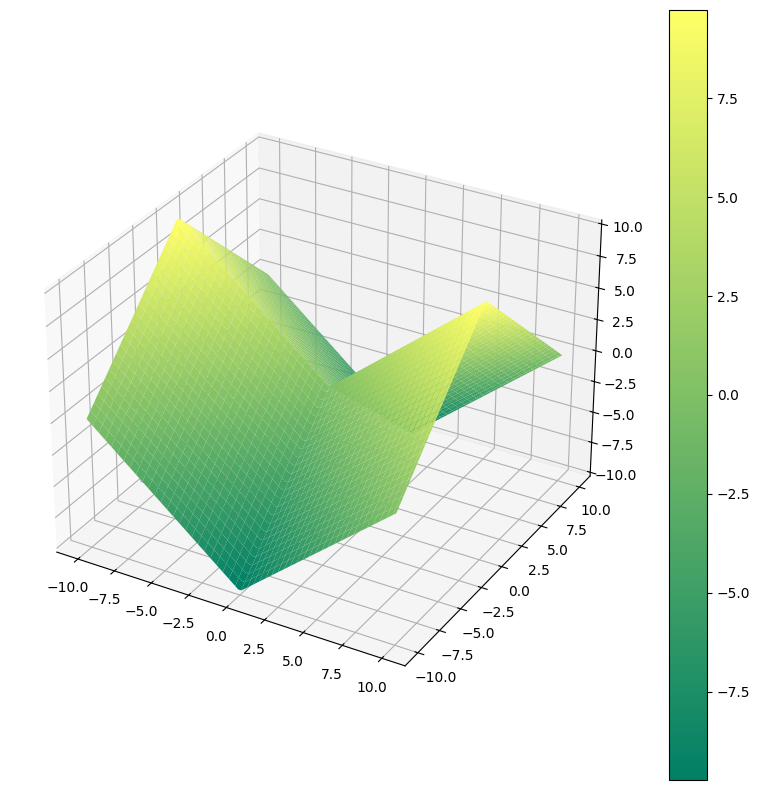

In [99]:
fig = plt.figure(figsize = (10,10))
ax = plt.subplot(projection = '3d')

p = ax.plot_surface(xx , yy , z , cmap = 'summer')

fig.colorbar(p)

### **Problem-4:** Draw the 3D *Contour plot* of this below equation:

$$z = |x| - |y|$$

In [105]:
x = np.linspace(-10 , 10 , 100)
y = np.linspace(-10 , 10 , 100)

xx , yy = np.meshgrid(x,y)

z = abs(xx) - abs(yy)
z

array([[ 0.00000000e+00, -2.02020202e-01, -4.04040404e-01, ...,
        -4.04040404e-01, -2.02020202e-01,  0.00000000e+00],
       [ 2.02020202e-01,  0.00000000e+00, -2.02020202e-01, ...,
        -2.02020202e-01,  1.77635684e-15,  2.02020202e-01],
       [ 4.04040404e-01,  2.02020202e-01,  0.00000000e+00, ...,
         0.00000000e+00,  2.02020202e-01,  4.04040404e-01],
       ...,
       [ 4.04040404e-01,  2.02020202e-01,  0.00000000e+00, ...,
         0.00000000e+00,  2.02020202e-01,  4.04040404e-01],
       [ 2.02020202e-01, -1.77635684e-15, -2.02020202e-01, ...,
        -2.02020202e-01,  0.00000000e+00,  2.02020202e-01],
       [ 0.00000000e+00, -2.02020202e-01, -4.04040404e-01, ...,
        -4.04040404e-01, -2.02020202e-01,  0.00000000e+00]])

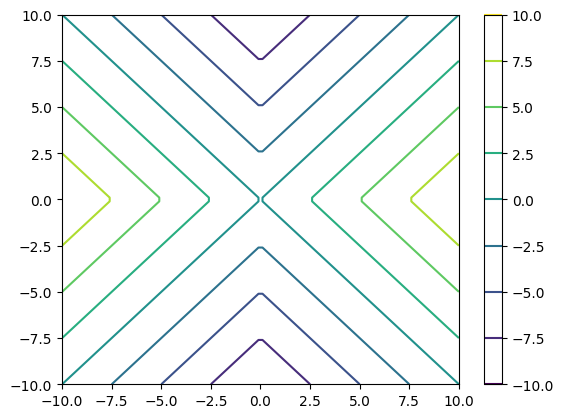

In [109]:
fig = plt.figure()
ax = plt.subplot()

p = ax.contour(xx , yy , z ,cmap='viridis')
fig.colorbar(p)

### **Problem-5:** Draw a second type of Countour plot of the below equation:

$$z = |x| - |y|$$

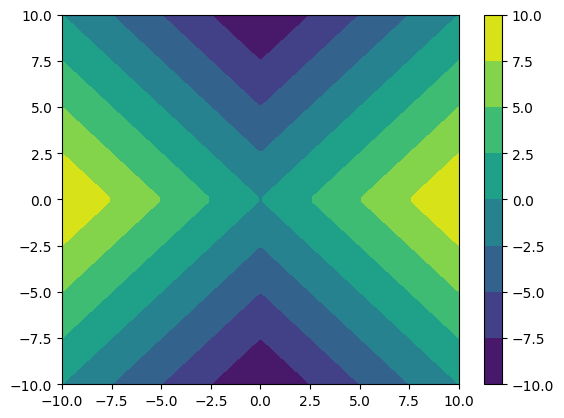

In [110]:
fig = plt.figure()
ax = plt.subplot()

p = ax.contourf(xx , yy , z ,cmap='viridis')
fig.colorbar(p)

## `Problem 6-7`

Data Set Link - https://docs.google.com/spreadsheets/d/17tUL2yC7MGvo7txuuhLtAI-b6_C4jc0t7FLFxqRm-uI/edit?usp=share_link


**Description of Dataset:**

* Date: It gives the date of which stocks details are given.
* Symbol: Name of stock
* Open: It gives the opening price of stock on that date.
* High: It gives the highest price to which the stock ascened on that day.
* Low: It gives the highest price to which the stock plummeted on that day.
* Close: It gives the closing price of stock on that date.
* Volume: It gives the amount of stock traded on that date.
* VWAP: The volume-weighted average price (VWAP) is a statistic used by traders to determine what the average price is based on both price and volume.
* Turnover:

In [114]:
nifty = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vSbaY6bnKXIj_ULv1eqkGirBYs7zYCA4mfmc9GbxR-epMX3Xkpe6sKndOpiKS19S2V3fIHZwDKFMYBe/pub?gid=1895610445&single=true&output=csv')
nifty

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades
0,2000-01-03,HDFCBANK,EQ,157.40,166.00,170.00,166.00,170.00,170.00,169.52,33259,5.638122e+11,NaN
1,2000-01-04,HDFCBANK,EQ,170.00,182.00,183.45,171.00,174.00,173.80,174.99,168710,2.952261e+12,NaN
2,2000-01-05,HDFCBANK,EQ,173.80,170.00,173.90,165.00,168.00,166.95,169.20,159820,2.704094e+12,NaN
3,2000-01-06,HDFCBANK,EQ,166.95,168.00,170.00,165.30,168.95,168.30,168.44,85026,1.432166e+12,NaN
4,2000-01-07,HDFCBANK,EQ,168.30,162.15,171.00,162.15,170.75,168.35,166.79,85144,1.420158e+12,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
480991,2021-04-26,POWERGRID,EQ,211.15,208.20,216.45,208.20,215.75,215.80,213.23,10765892,2.295642e+14,72260.0
480992,2021-04-27,POWERGRID,EQ,215.80,216.05,220.50,215.80,216.40,216.65,217.89,8589721,1.871605e+14,77004.0
480993,2021-04-28,POWERGRID,EQ,216.65,218.80,221.70,216.30,221.35,220.90,219.20,9215766,2.020103e+14,55866.0
480994,2021-04-29,POWERGRID,EQ,220.90,223.10,223.65,219.05,219.80,220.15,220.60,8303610,1.831748e+14,48655.0


### `Problem-6` Use Pandas plot functions

* Line plot of closing value of top 5 Stocks in Year 2020.
* Take top 5 stocks based on total turnover in Year 2020

In [117]:
nifty['Date'] = pd.to_datetime(nifty['Date'])  # converted Date datatype to date time

In [133]:
temp = nifty[nifty['Date'].dt.year == 2020]
top_5 = temp.groupby('Symbol')['Turnover'].sum().sort_values(ascending = False).head().index

In [140]:
temp_top5 = temp[temp['Symbol'].isin(top_5)]

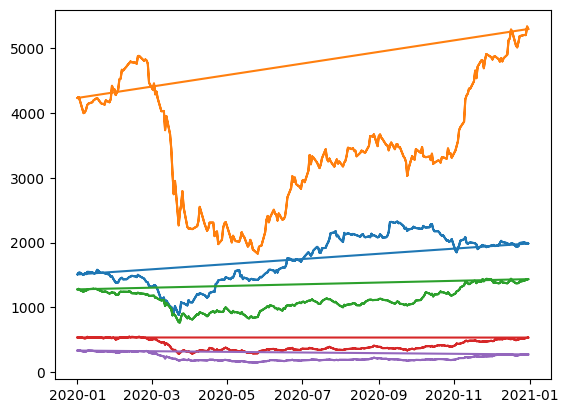

In [143]:
for symbol in top_5:
    subset = temp_top5[temp_top5['Symbol'] == symbol]
    plt.plot(subset['Date'], subset['Close'], label=symbol)

### `Problem-7` Scatter plot Close price vs Volume for TOP-5 Stocks in year 2021
* Color on Symbol Column

In [160]:
temp_df = nifty[nifty['Date'].dt.year == 2021]
temp_df.groupby('Symbol')['Turnover'].sum().sort_values(ascending = False).head().index

Index(['TATAMOTORS', 'RELIANCE', 'SBIN', 'TATASTEEL', 'HDFCBANK'], dtype='object', name='Symbol')

<Axes: xlabel='Close', ylabel='Volume'>

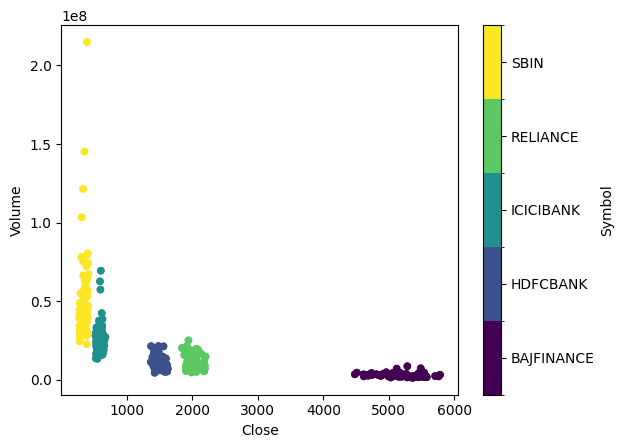

In [161]:

temp_df = temp_df[temp_df['Symbol'].isin(top_5)]

temp_df['Symbol'] = temp_df['Symbol'].astype('category')
temp_df.plot(kind='scatter', x='Close', y='Volume', c='Symbol', colormap='viridis')


### `Problem-8` Create a 3-D Scatter Plot using `time,x,y` on below synthetic data. and give color gradiant on `z`
```
# Create a 3D dataset
time = np.linspace(0, 10, 100)
x = np.sin(time)
y = np.cos(time)
z = time

# Create a DataFrame from the dataset
data = pd.DataFrame({'time': time, 'x': x, 'y': y, 'z': z})
```